# ReGRID model analysis
### for visualizing energy system transitions

Note:
- This notebook depends on output files generated by the following notebooks:
  - model_DC.ipynb
  - analysis_system.ipynb

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import os

In [2]:
# Model definition

TERM = '1y'
STEP = 6
VER = 'v7'
BOUNDARY = 'japan'
PATHWAY = 'C1'
NUCLEAR_AVAILABILITY = 1
POTENTIAL_AVAILABILITY= 50
POTENTIAL_CASE = 'base'
COST_CASE = 'moderate'
DC_SCENARIO = 'NoDC' # 'Low','Mid','High','NoDC'
DC_STRATEGY = 'NoDC' # 'BAU','ILA','DEV'(=FLEX),'NoDC'

In [3]:
dir = f"ReGRID2_{VER}_analysis_{TERM}_{STEP}_{BOUNDARY}_n{NUCLEAR_AVAILABILITY}_p{POTENTIAL_AVAILABILITY}_{POTENTIAL_CASE}_{COST_CASE}"
if not os.path.exists(dir):
    os.makedirs(f'output/{dir}', exist_ok=True)
print(dir)

ReGRID2_v7_analysis_1y_6_japan_n1_p50_base_moderate


In [4]:
# Data for analysis

# Parameters
P = pd.read_csv(f'input/technology/technology_{PATHWAY}.csv', index_col=0)
P = P[(P['year'] == 2050) & (P['scenario'] == COST_CASE)]

# Region list
region_list = pd.read_csv('input/region.csv', index_col='code', dtype={'code':str, 'DSN':str})
REGION = region_list.index.to_list() # All nodes
SUBSTATION = pd.read_csv('input/region_substation.csv', index_col=0, dtype={'region':str})['region'].to_list() # Substation nodes
NODE = [r for r in REGION if r not in SUBSTATION] # Resource nodes
AREA = region_list['DSN'].copy() # Distribution area
AREA_DICT = AREA.reset_index().groupby('DSN')['code'].apply(list).to_dict() # Distribution area dictionary
REGION06 = pd.Series(data=[f"{r:>6}".replace(' ','_') for r in REGION], index=REGION) # Region list (6 digit code)
SPREGION = {}

# Technology list
RESOURCE = ['hydro','geoth','river','onwin','of-fx','of-fl','solar']
RESOURCE_NOHYDRO = ['geoth','river','onwin','of-fx','of-fl','solar']
WASTE = ['waste','msw-c']
WOODY = ['woody','beccs']
THERMAL = ['oil-p','coalp','coalc','gas-p','gas-c','nuclr']
STORAGE = ['stpmp','stbat']
H2TECH = ['st-h2','h2cmp','el-h2','h2-el']
DACCS = ['daccs']

tech_order = ['onwin', 'of-fx', 'of-fl', 'solar', 'waste', 'msw-c', 'woody', 'beccs', 'coalp', 'coalc', 'gas-p', 'gas-c', 'oil-p', 'nuclr', 'hydro', 'geoth', 'river', 'stpmp', 'stbat', 'st-h2', 'h2cmp', 'el-h2', 'h2-el', 'ih2-f', 'daccs', 'grid']

# JPY -> USD
USD = 107 # TTM in 2020

In [5]:
# Chart paramter
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.direction'] = 'out'
plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['ytick.major.width'] = 0.5
plt.rcParams['xtick.major.size'] = 2.5
plt.rcParams['ytick.major.size'] = 2.5
plt.rcParams['font.size'] = 7
plt.rcParams['xtick.labelsize'] = 7
plt.rcParams['ytick.labelsize'] = 7
plt.rcParams['axes.linewidth'] = 0.5

MAX_WIDTH = 180 / 25.4 # inch in 180mm

In [ ]:
scenario_name = {'C1':'1.5C','C3':'WB2C','C7':'4C'}

def transition_plot(data, title, ymin, ymax, file_name, legend_size):
    fig, ax = plt.subplots(1, 1, gridspec_kw={'wspace':0.04}, figsize=(MAX_WIDTH*0.45, MAX_WIDTH*0.45), dpi=300)

    # Stack plot
    data.plot(kind='area', stacked=True, ax=ax, color=[P['color'][abr] for abr in data.columns], legend=None, linewidth=0)
    ax.tick_params(bottom=False, pad=2, axis='y')
    ax.tick_params(pad=2, axis='x')
    ax.set_ylabel(title)
    ax.set_xlabel("", fontsize=0)
    ax.set_ylim(ymin, ymax)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title(DC_STRATEGY, fontsize=7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Legend
    handles, labels = ax.get_legend_handles_labels() 
    plt.legend(handles[::-1], [P['name'][abr] for abr in data.columns][::-1], bbox_to_anchor=(1.01, 1.02), labelspacing=0.24, loc='upper left', frameon = False, fontsize=legend_size, ncol=1)

    plt.savefig(f'output/{dir}/{file_name}.jpg', bbox_inches='tight', dpi=300)
    plt.savefig(f'output/{dir}/{file_name}.eps', bbox_inches='tight', dpi=300)
    plt.show()

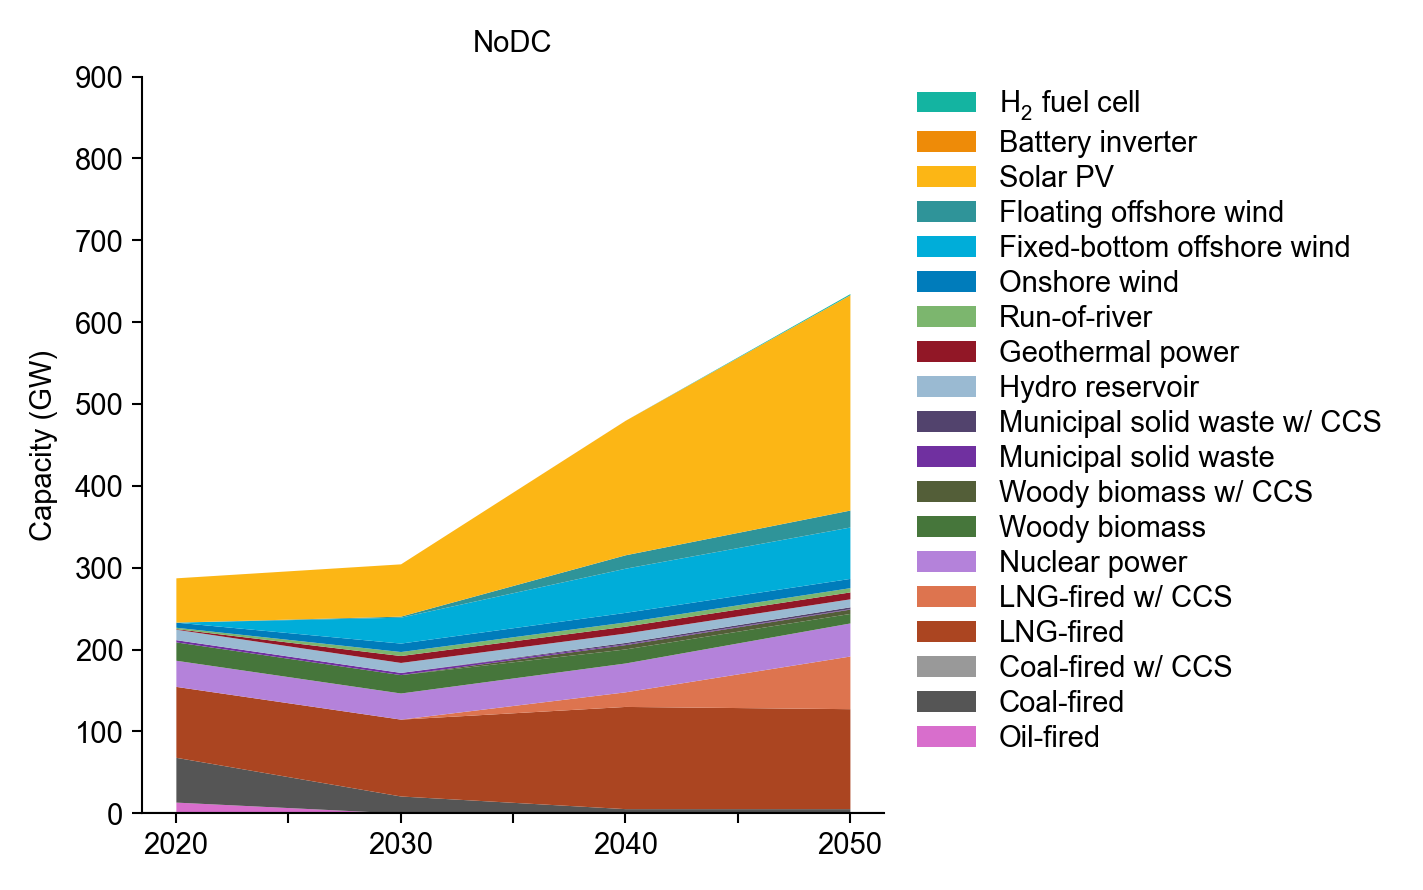

In [7]:
# Capacity data

YEAR = ['2020', '2030', '2040', '2050']

capacity = pd.DataFrame(columns=['node','tech','MW','year'])

for year in YEAR:
    model_name = f"ReGRID2_{VER}_{year}_{PATHWAY}_{TERM}_{STEP}_{BOUNDARY}_n{NUCLEAR_AVAILABILITY}_p{POTENTIAL_AVAILABILITY}_{POTENTIAL_CASE}_{COST_CASE}_{DC_SCENARIO}_{DC_STRATEGY}"
    if os.path.exists(f'output/{model_name}/capacity_total_{year}.csv'):
        if year == '2020':
            capacity = pd.read_csv(f'output/{model_name}/capacity_total_{year}.csv', dtype={'node':str, 'year':str})
        else:
            capacity = pd.concat([capacity, pd.read_csv(f'output/{model_name}/capacity_total_{year}.csv', dtype={'node':str, 'year':str})])
    else:
        print("No data: "+f"output/{model_name}/capacity_total_{year}.csv")

capacity = capacity.groupby(['tech','year']).sum()['MW'].unstack().fillna(0) / 1000 # MW -> GW
capacity = capacity.T.loc[:,THERMAL + WOODY + WASTE + RESOURCE + ['stpcs','h2-el']]

transition_plot(capacity, "Capacity (GW)", 0, 900, f'capacity_transition_{PATHWAY}_{DC_SCENARIO}_{DC_STRATEGY}', 7)

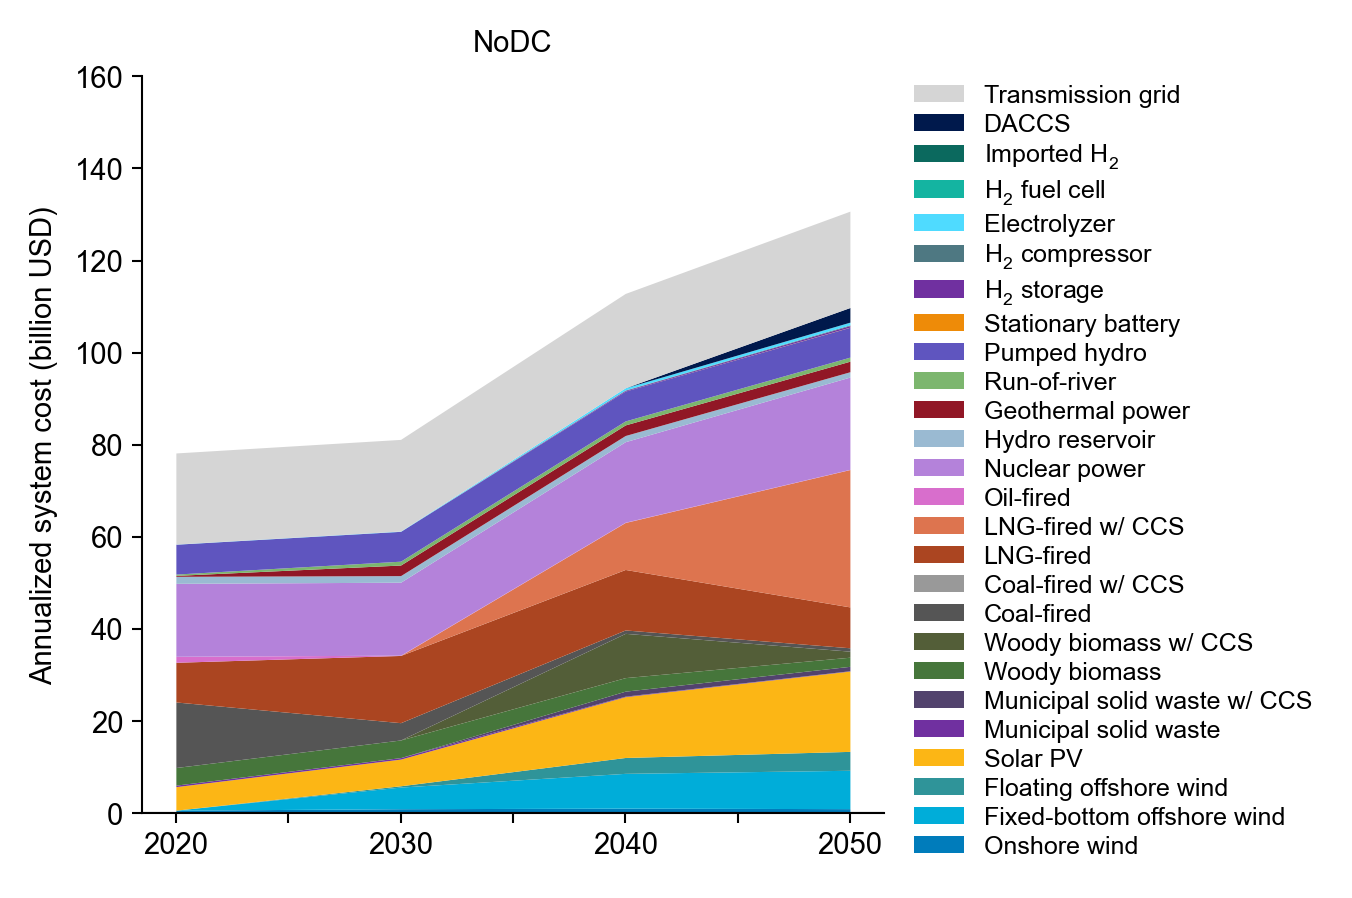

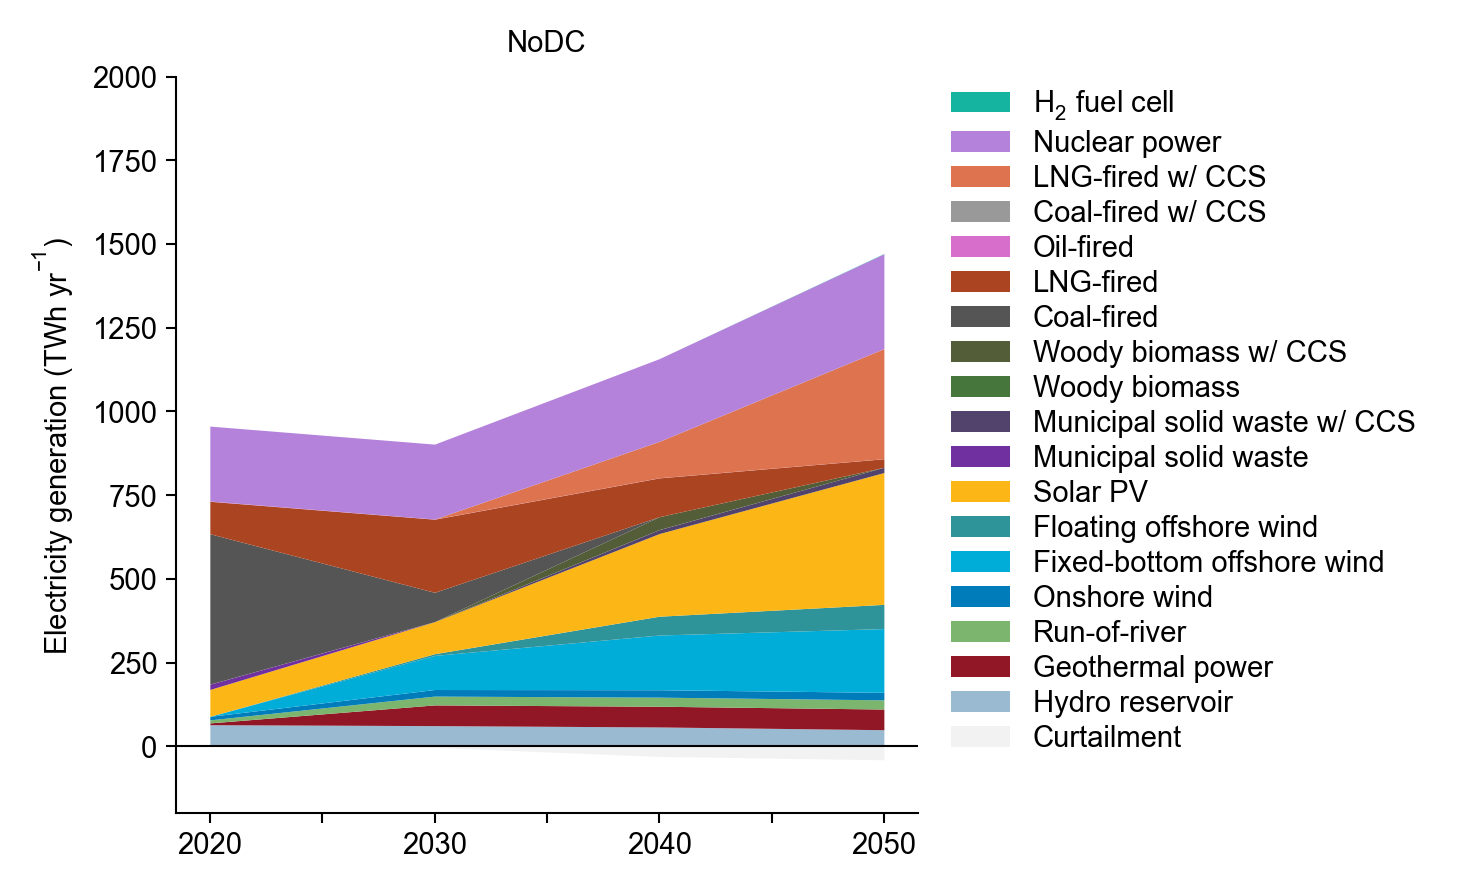

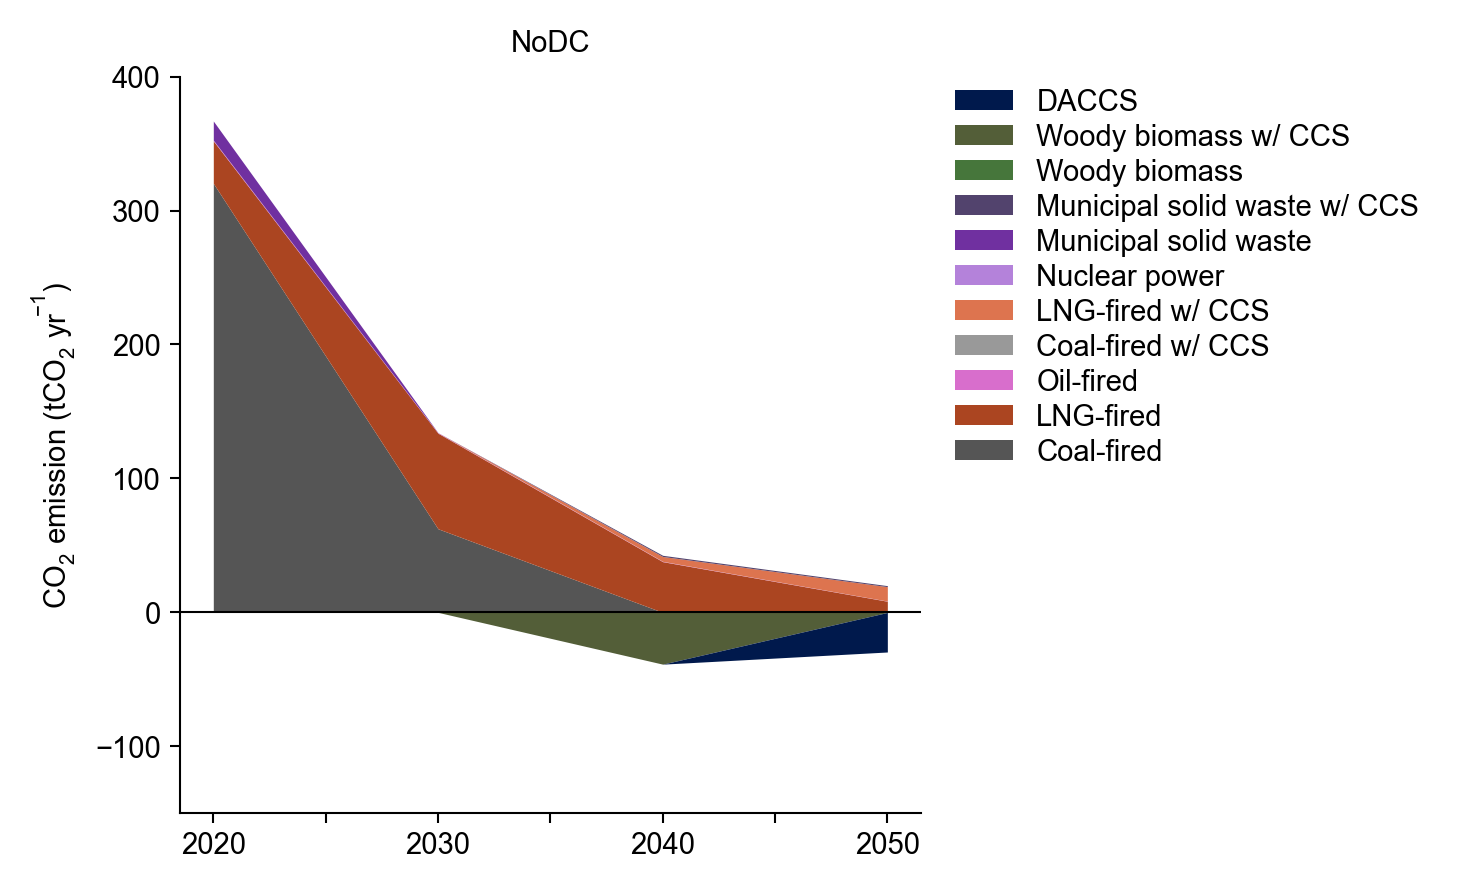

In [8]:
# Transition data

cost = pd.DataFrame()
generation = pd.DataFrame()
emission = pd.DataFrame()
for year in YEAR:
    model_name = f"ReGRID2_{VER}_{year}_{PATHWAY}_{TERM}_{STEP}_{BOUNDARY}_n{NUCLEAR_AVAILABILITY}_p{POTENTIAL_AVAILABILITY}_{POTENTIAL_CASE}_{COST_CASE}_{DC_SCENARIO}_{DC_STRATEGY}"
    cost[year] = pd.read_csv('output/%s/cost_%s.csv' % (model_name,model_name), index_col=0, dtype={'region':str, 'time':str})
    generation[year] = pd.read_csv('output/%s/generation_%s.csv' % (model_name,model_name), index_col=0)
    emission[year] = pd.read_csv('output/%s/emission_%s.csv' % (model_name,model_name), index_col=0)

cost = cost.abs().T / USD * 1000 # trillion JPY -> billion USD
cost = cost[tech_order] # Sort
generation = generation.T / 1000000 # MWh -> TWh
emission = emission.T # tCO2

# Draw
transition_plot(cost, "Annualized system cost (billion USD)", 0, 160, f'cost_transition_{PATHWAY}_{DC_SCENARIO}_{DC_STRATEGY}', 6)
transition_plot(generation, r"Electricity generation (TWh yr$^{-1}$)", -200, 2000, f'generation_transition_{PATHWAY}_{DC_SCENARIO}_{DC_STRATEGY}', 7)
transition_plot(emission, r"CO$_{2}$ emission (tCO$_{2}$ yr$\!^{-1}$)", -150, 400, f'emission_transition_{PATHWAY}_{DC_SCENARIO}_{DC_STRATEGY}', 7)